In [1]:
import pandas as pd
from pandas.api.types import is_float_dtype, is_integer_dtype
import numpy as np
import os
import masking_effects_on_xai_techniques.hierarchies as hi
import textwrap

from anjana.anonymity import (
    k_anonymity_inner,
    k_anonymity,
    l_diversity,
    t_closeness,
    alpha_k_anonymity,
)

from masking_effects_on_xai_techniques import finding_k
from masking_effects_on_xai_techniques import anonymized_preprocessor as anon_prep
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE, RandomOverSampler

In [2]:
def create_disease_encoding(df):
    features = ["Hinselmann", "Schiller", "Citology", "Biopsy"]

    df[features] = df[features].astype(int)

    df["disease"] = (
        (df["Hinselmann"] * 8)
        + (df["Schiller"] * 4)
        + (df["Citology"] * 2)
        + (df["Biopsy"] * 1)
    )

    mapping = {}

    for encoding_value in range(16):
        binary_string = format(encoding_value, "04b")

        combination = tuple(int(bit) for bit in binary_string)
        combination_str = ""
        for i, feat in enumerate(features):
            if combination[i] == 1:
                combination_str += f"{feat}, "

        if combination_str:
            combination_str = combination_str[:-2]
        else:
            combination_str = "No Disease"

        mapping[encoding_value] = combination_str

    return df, mapping

In [3]:
os.chdir("..")
pd.set_option("display.max_columns", None)

# Preprocessing

In [4]:
df = pd.read_csv("./data/cervic_cancer/data.csv")
df = df.replace("?", np.nan)

# Convert target features to one feature
target_features = ["Hinselmann", "Schiller", "Citology", "Biopsy"]
df, disease_map = create_disease_encoding(df)
target_df = df[target_features]
df = df.drop(target_features, axis=1)

# Drop other tagert features
df = df.drop(["Dx:Cancer", "Dx:CIN", "Dx:HPV", "Dx"], axis=1)

df.columns = df.columns.str.replace(")", "_", regex=False)
df.columns = df.columns.str.replace("(", "_", regex=False)
df.columns = df.columns.str.replace("/", "-", regex=False)

In [5]:
df

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes _years_,Smokes _packs-year_,Hormonal Contraceptives,Hormonal Contraceptives _years_,IUD,IUD _years_,STDs,STDs _number_,STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,disease
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
854,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0
855,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,2
856,33,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0


## NaN Values
The dataset has a lot of NaN values. We now consider those

In [6]:
print(f"{'Feature':.<{40}} # NoN Null Frac")
for feat in df.columns:
    non_null = df[feat].notnull().sum()
    frac = round(non_null / df.shape[0] * 100, 1)

    print(f"{feat:.<{40}} {non_null:<{10}} {frac}")

Feature................................. # NoN Null Frac
Age..................................... 858        100.0
Number of sexual partners............... 832        97.0
First sexual intercourse................ 851        99.2
Num of pregnancies...................... 802        93.5
Smokes.................................. 845        98.5
Smokes _years_.......................... 845        98.5
Smokes _packs-year_..................... 845        98.5
Hormonal Contraceptives................. 750        87.4
Hormonal Contraceptives _years_......... 750        87.4
IUD..................................... 741        86.4
IUD _years_............................. 741        86.4
STDs.................................... 753        87.8
STDs _number_........................... 753        87.8
STDs:condylomatosis..................... 753        87.8
STDs:cervical condylomatosis............ 753        87.8
STDs:vaginal condylomatosis............. 753        87.8
STDs:vulvo-perineal condylomat

We drop all rows that has under 33% NaN values  

Below we fil nan with mean or median depending on the datatype. If feature is whole number (likely a category) it is the median, otherwise it is the mean

In [7]:
frac_nan = 0.33
# Convert to Numeric
for feat in df.columns:
    col = pd.to_numeric(df[feat])
    non_nan = col.dropna()
    frac_non_nan = len(non_nan.dropna()) / len(col)
    if frac_non_nan < frac_nan:
        df = df.drop([feat], axis=1)
        continue

    is_whole_number = np.all(np.isclose(non_nan, non_nan.round()))
    if is_whole_number:
        col = col.fillna(col.median())
    else:
        col = col.fillna(col.mean())
    df[feat] = col

In [8]:
df

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes _years_,Smokes _packs-year_,Hormonal Contraceptives,Hormonal Contraceptives _years_,IUD,IUD _years_,STDs,STDs _number_,STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,disease
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
854,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
855,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2
856,33,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [9]:
df.nunique()

Age                                   44
Number of sexual partners             12
First sexual intercourse              21
Num of pregnancies                    11
Smokes                                 2
Smokes _years_                        31
Smokes _packs-year_                   63
Hormonal Contraceptives                2
Hormonal Contraceptives _years_       41
IUD                                    2
IUD _years_                           27
STDs                                   2
STDs _number_                          5
STDs:condylomatosis                    2
STDs:cervical condylomatosis           1
STDs:vaginal condylomatosis            2
STDs:vulvo-perineal condylomatosis     2
STDs:syphilis                          2
STDs:pelvic inflammatory disease       2
STDs:genital herpes                    2
STDs:molluscum contagiosum             2
STDs:AIDS                              1
STDs:HIV                               2
STDs:Hepatitis B                       2
STDs:HPV        

The fact that HIV and the other long thing only has one kind of events, is because no one has it. These do not add anything to the model, since they are identical for all instances, and therefore they are dropped.

In [10]:
df = df.drop(["STDs:AIDS", "STDs:cervical condylomatosis"], axis=1)

# Over-Sample Minority Classes
We want to oversample the minority classes such. If we do not do that, the models trained become useless. They simply guess 0 because that is the dominant class

In [11]:
X = df.drop("disease", axis=1)
y = df["disease"]
X_resampled, y_resampled = RandomOverSampler(random_state=0).fit_resample(X, y)
y_resampled.name = "disease"
# df = pd.concat([X_resampled, y_resampled], axis=1)

# Defining Hierarchies
We not want to create taxonomies for each feature  
The idea is simple. All features with two or less number of values are considered binary. Simple taxonomy trees for those are generated. They are already at their highest generalization level, so the only thing to do is to suppress them completely once they get generalized once.  
For numeric features we can use our normal approaches

In [12]:
# Find binary features
bin_feat = []
num_feat = []
for feat, n in zip(df.columns, df.nunique()):
    if n == 2:
        bin_feat.append(feat)
    else:
        num_feat.append(feat)

## Binary Features

In [13]:
for feat in bin_feat:
    print(f"{feat:.<{40}} {df[feat].mean()}")
    # print(f"{df[feat].value_counts(normalize=True)}")

Smokes.................................. 0.14335664335664336
Hormonal Contraceptives................. 0.6864801864801865
IUD..................................... 0.09673659673659674
STDs.................................... 0.09207459207459208
STDs:condylomatosis..................... 0.05128205128205128
STDs:vaginal condylomatosis............. 0.004662004662004662
STDs:vulvo-perineal condylomatosis...... 0.05011655011655012
STDs:syphilis........................... 0.02097902097902098
STDs:pelvic inflammatory disease........ 0.0011655011655011655
STDs:genital herpes..................... 0.0011655011655011655
STDs:molluscum contagiosum.............. 0.0011655011655011655
STDs:HIV................................ 0.02097902097902098
STDs:Hepatitis B........................ 0.0011655011655011655
STDs:HPV................................ 0.002331002331002331


This might be a problem. Some of these are very skewed, making anonymization difficult

In [14]:
# Write simple taxonomies to hierarchies
hierarchies_path = "./hierarchies/cervic_cancer"
for feat in bin_feat:
    with open(f"{hierarchies_path}/{feat}.csv", "w") as f:
        for val in df[feat].unique():
            f.write(f"{val}, *\n")

## Numeric Features

In [15]:
def create_and_save(feat, n):
    hiear = hi.generate_qcut_hierarchy(df[feat], n, search_for_n=True)
    hi.save_hierarchy(hiear, f"{hierarchies_path}/{feat}.csv")

In [16]:
for feat in num_feat:
    try:
        create_and_save(feat, 3)
        print(f"Generated hierarchy for {feat}")
    except RuntimeError:
        print("failed for " + feat)

Generated hierarchy for Age
Generated hierarchy for Number of sexual partners
Generated hierarchy for First sexual intercourse
Generated hierarchy for Num of pregnancies
Generated hierarchy for Smokes _years_
Generated hierarchy for Smokes _packs-year_
Generated hierarchy for Hormonal Contraceptives _years_
Generated hierarchy for IUD _years_
Generated hierarchy for STDs _number_
Generated hierarchy for STDs: Number of diagnosis
Generated hierarchy for disease


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/pandas/core/indexes/base.py:7819: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values).astype(str)
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/p

Semantically, some of these might not make sense. The number of pregnancies a person can have can be between 0.8 and 2,4.  
The algorithm failed to generate hierarchies for two features. We consider those by hand

In [17]:
feat = "STDs _number_"
df[feat].value_counts()

STDs _number_
0.0    779
2.0     37
1.0     34
3.0      7
4.0      1
Name: count, dtype: int64

This feature is so skewed, that it is almost impossible to generalize meaningfully with a taxonomy tree. Even if we split it so all 0 are together and everything else is together, only 7% would be in the non-zero categoy. For now we try and create it by hand, but it might turn out bad when we anonymize

In [18]:
with open(f"{hierarchies_path}/{feat}.csv", "w") as f:
    content = textwrap.dedent(
        """
0.0, "(-0.001, 1.0]",*
1.0, "(1.0, 5.0]",*
2.0, "(1.0, 5.0]",*
3.0, "(1.0, 5.0]",*
4.0, "(1.0, 5.0]",*
"""
    ).strip()

    f.write(content + "\n")

In [19]:
feat = "STDs: Number of diagnosis"
df[feat].value_counts()

STDs: Number of diagnosis
0    787
1     68
2      2
3      1
Name: count, dtype: int64

Same story

In [20]:
with open(f"{hierarchies_path}/{feat}.csv", "w") as f:
    content = textwrap.dedent(
        """
0, "(-0.001, 1.0]",*
1, "(1.0, 3.0]",*
2, "(1.0, 3.0]",*
3, "(1.0, 3.0]",*
"""
    ).strip()

    f.write(content + "\n")

# Anonymization

In [21]:
hierarchies = {}
for feat in df.columns:
    hierarchies[feat] = dict(pd.read_csv(f"{hierarchies_path}/{feat}.csv", header=None))

In [22]:
quasi_ident = list(df.columns)
quasi_ident.remove("disease")

ident = []
sens_att = "disease"

In [23]:
all_counts_and_features = []
for feat, items in hierarchies.items():
    for item in items.values():
        length = len(item.unique())
        all_counts_and_features.append((length, feat))
sorted_data = sorted(all_counts_and_features, key=lambda x: x[0], reverse=True)
ordered_features = [feat for count, feat in sorted_data]

for feat, items in hierarchies.items():
    lengths = [f"{len(item.unique()):>4}" for item in items.values()]
    out = ", ".join(lengths)
    print(f"{feat:<15}: {out}")

print("Order in which features will be generalized:")
print(ordered_features)

Age            :   44,    3,    2,    1
Number of sexual partners:   12,    3,    2,    1
First sexual intercourse:   21,    3,    2,    1
Num of pregnancies:   11,    3,    2,    1
Smokes         :    2,    1
Smokes _years_ :   31,    3,    2,    1
Smokes _packs-year_:   63,    3,    2,    1
Hormonal Contraceptives:    2,    1
Hormonal Contraceptives _years_:   41,    3,    2,    1
IUD            :    2,    1
IUD _years_    :   27,    3,    2,    1
STDs           :    2,    1
STDs _number_  :    5,    2,    2,    1
STDs:condylomatosis:    2,    1
STDs:vaginal condylomatosis:    2,    1
STDs:vulvo-perineal condylomatosis:    2,    1
STDs:syphilis  :    2,    1
STDs:pelvic inflammatory disease:    2,    1
STDs:genital herpes:    2,    1
STDs:molluscum contagiosum:    2,    1
STDs:HIV       :    2,    1
STDs:Hepatitis B:    2,    1
STDs:HPV       :    2,    1
STDs: Number of diagnosis:    4,    2,    2,    1
disease        :   13,    3,    2,    1
Order in which features will be generali

In [24]:
%%time
# Check with mina if this k is representative of used k in litterature
k = 20
supp_level = 10  # Select the suppression limit allowed
anon_df, supp_n, hiear = k_anonymity_inner(
    df, ident, quasi_ident, k, supp_level, hierarchies
)
max_supp_n = int(round(len(df) * supp_level / 100, 0))
print(f"Max rows that can be suppressed: {max_supp_n}")
print(f"Rows suppressed                : {supp_n}")
print(f"% of allowed rows suppressed   : {round(supp_n / max_supp_n * 100, 1)}%")
print(f"Generalization level           : {sum(hiear.values())}")
hiear

Max rows that can be suppressed: 86
Rows suppressed                : 67
% of allowed rows suppressed   : 77.9%
Generalization level           : 26
CPU times: user 489 ms, sys: 0 ns, total: 489 ms
Wall time: 488 ms


{'Age': 3,
 'Number of sexual partners': 3,
 'First sexual intercourse': 3,
 'Num of pregnancies': 3,
 'Smokes': 1,
 'Smokes _years_': 3,
 'Smokes _packs-year_': 3,
 'Hormonal Contraceptives': 1,
 'Hormonal Contraceptives _years_': 2,
 'IUD': 0,
 'IUD _years_': 2,
 'STDs': 0,
 'STDs _number_': 1,
 'STDs:condylomatosis': 0,
 'STDs:vaginal condylomatosis': 0,
 'STDs:vulvo-perineal condylomatosis': 0,
 'STDs:syphilis': 0,
 'STDs:pelvic inflammatory disease': 0,
 'STDs:genital herpes': 0,
 'STDs:molluscum contagiosum': 0,
 'STDs:HIV': 0,
 'STDs:Hepatitis B': 0,
 'STDs:HPV': 0,
 'STDs: Number of diagnosis': 1}

In [25]:
anon_df

,index,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes _years_,Smokes _packs-year_,Hormonal Contraceptives,Hormonal Contraceptives _years_,IUD,IUD _years_,STDs,STDs _number_,STDs:condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,disease
0,0,*,*,*,*,*,*,*,*,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,"""(-0.001",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""(-0.001",0
1,1,*,*,*,*,*,*,*,*,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,"""(-0.001",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""(-0.001",0
2,2,*,*,*,*,*,*,*,*,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,"""(-0.001",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""(-0.001",0
3,3,*,*,*,*,*,*,*,*,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,"""(-0.001",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""(-0.001",0
4,4,*,*,*,*,*,*,*,*,"(3.5, 30.0]",0.0,"(-0.001, 2.0]",0.0,"""(-0.001",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""(-0.001",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,853,*,*,*,*,*,*,*,*,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,"""(-0.001",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""(-0.001",0
787,854,*,*,*,*,*,*,*,*,"(3.5, 30.0]",0.0,"(-0.001, 2.0]",0.0,"""(-0.001",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""(-0.001",0
788,855,*,*,*,*,*,*,*,*,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,"""(-0.001",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""(-0.001",2
789,856,*,*,*,*,*,*,*,*,"(-0.001, 3.5]",0.0,"(-0.001, 2.0]",0.0,"""(-0.001",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""(-0.001",0


Note how all features from left to right slowly get suppressed. The anonymization algorithm probably generalizes all features until they all become binary. Then it probably anonymizes the features in the order they appear in `df.columns`. 

# Finding K

In [26]:
anon_data = finding_k.generate_k_anonymity_data(df, 20, ident, quasi_ident, hierarchies)

Anonymizing for k=2
Anonymizing for k=4
Anonymizing for k=8
Anonymizing for k=16
Anonymizing for k=32
Anonymizing for k=64
Anonymizing for k=128
Anonymizing for k=256
Done anonymizing


In [27]:
models, scores = finding_k.train_models(anon_data, "disease", hierarchies_path)

0.8723404255319149


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.872791519434629
0.8936170212765957


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9032258064516129
0.9090909090909091


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9014084507042254
0.9014084507042254
0.9014084507042254


This is a problem. I think the model just gueses 0 all the time. Because there is such a high imbalance, the model gets a good accuracy

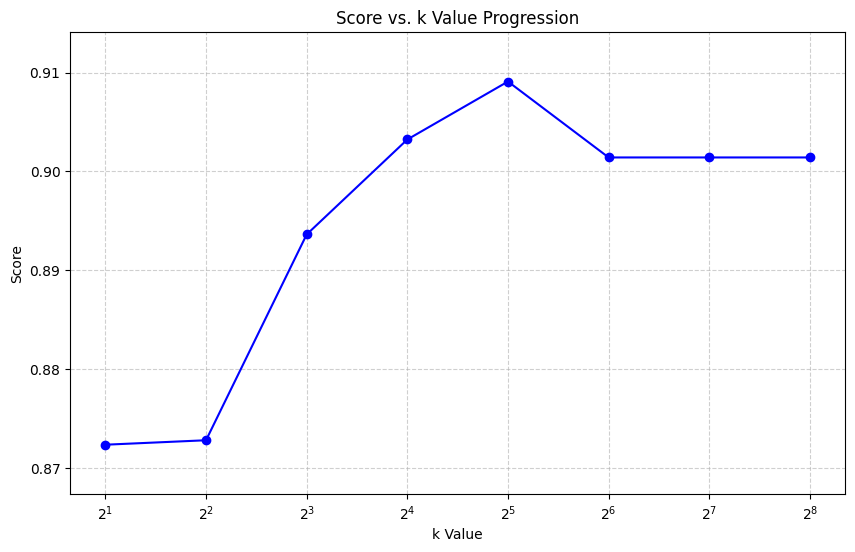

In [28]:
finding_k.plot_k_vs_score(scores)

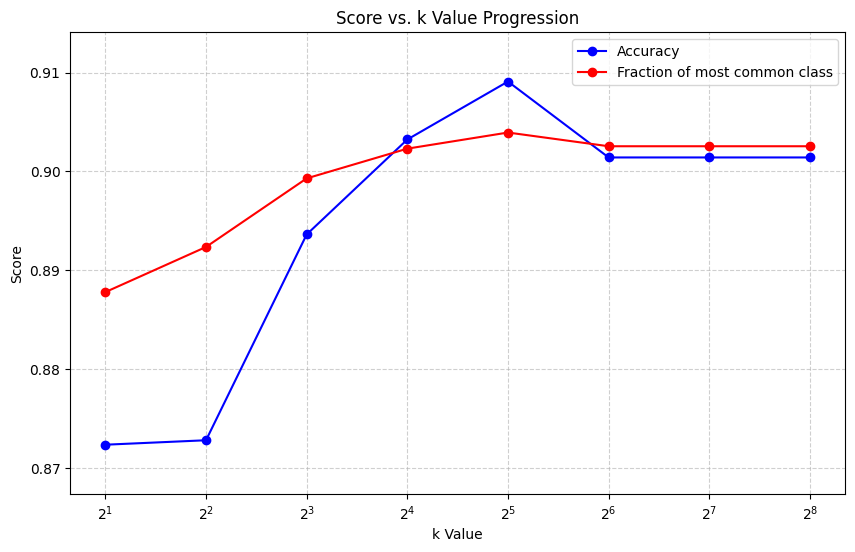

In [29]:
k_list = [2**n for n in range(1, 9)]
a = [
    anon_data[i]["disease"].value_counts(normalize=True)[0]
    for i in range(len(anon_data))
]
df = pd.DataFrame({"k_value": k_list, "Score": scores, "a": a})

plt.figure(figsize=(10, 6))

plt.plot(df["k_value"], df["Score"], marker="o", linestyle="-", color="blue")
plt.plot(df["k_value"], df["a"], marker="o", linestyle="-", color="red")

plt.xscale("log", base=2)

plt.xlabel("k Value")
plt.ylabel("Score")
plt.title("Score vs. k Value Progression")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(["Accuracy", "Fraction of most common class"])

plt.xticks(k_list)

min_score = min(scores) - 0.005
max_score = max(scores) + 0.005
plt.ylim(min_score, max_score)
plt.show()

Below we have the same plot for random forest
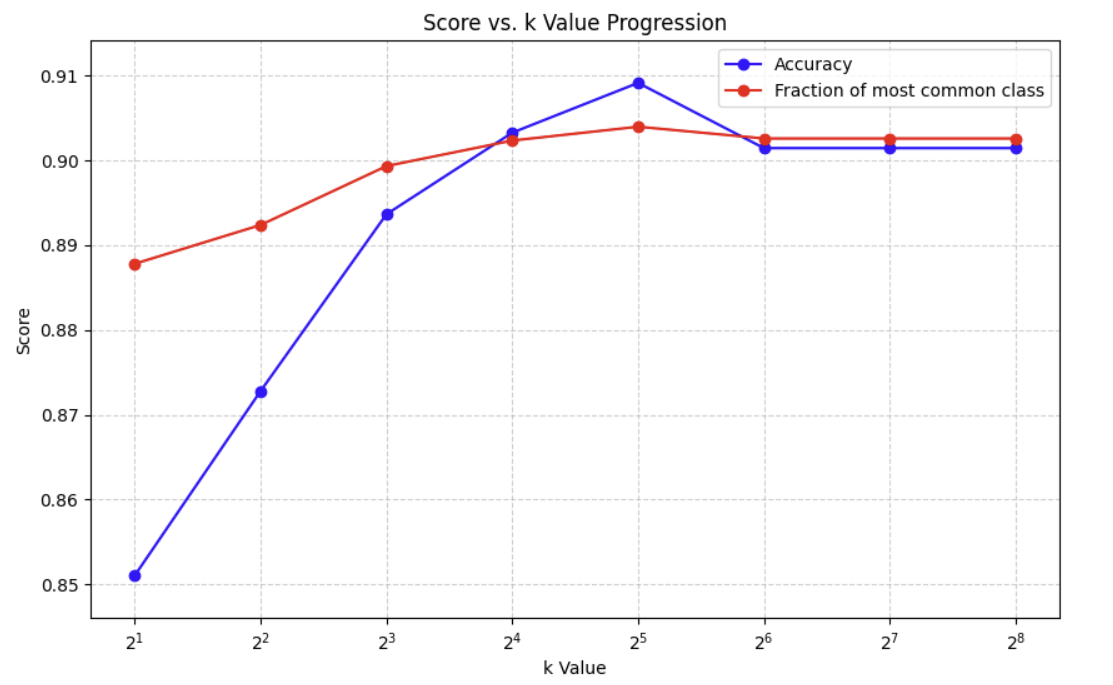

It most likely guesses. The red line takes into account all values, it does not look at the train / test split. 